
Data loaded...

Column of interest: Largest free sphere (aka pore limiting diameter, PLD)

Target variable shape (y): (124467,)
Feature matrix shape (X):  (124467, 6)
Number of predictors:      6
Predictor Columns:
['Unitcell_volume', 'Density', 'NASA_A^2', 'Largest included sphere along free sphere path', 'POAV_cm^3/g', 'PONAV_cm^3/g']

Initialized GroupKFold with 5 splits.
Initialized RandomForestRegressor with 100 n_estimators.

Beginning 5-Fold GroupKFold Cross-Validation...

Fold #1 -> R²: 0.9348 | MAE: 0.3202 Å | RMSE: 0.5009 Å
Fold #2 -> R²: 0.9339 | MAE: 0.3217 Å | RMSE: 0.5090 Å
Fold #3 -> R²: 0.9366 | MAE: 0.3215 Å | RMSE: 0.5211 Å
Fold #4 -> R²: 0.9325 | MAE: 0.3237 Å | RMSE: 0.5204 Å
Fold #5 -> R²: 0.9406 | MAE: 0.3211 Å | RMSE: 0.4893 Å

Model Performance Summary
R² Score:     0.9357 (± 0.0028)
MAE:  0.3216 Å (± 0.0012 Å)
RMSE: 0.5081 Å (± 0.0121 Å)

Check - Training Data Performance Summary
R² Score:     0.9919 (± 0.0001)
MAE:  0.1140 Å (± 0.0002 Å)
RMSE: 0.1807 Å (± 0.0

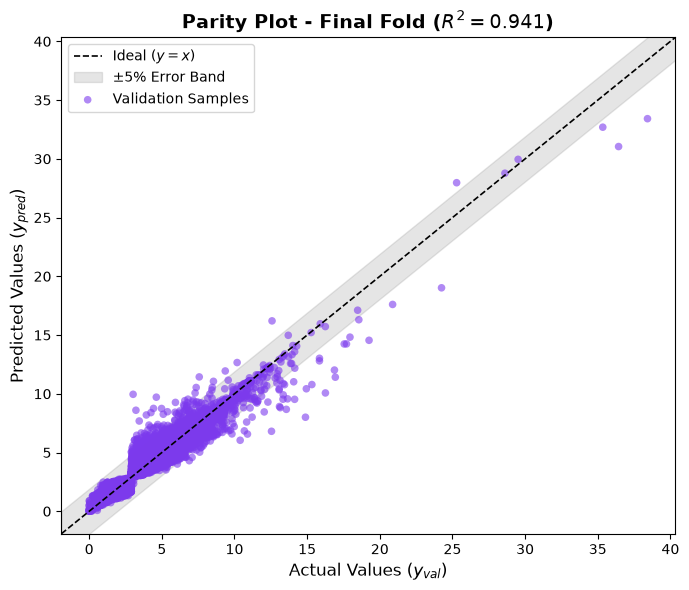

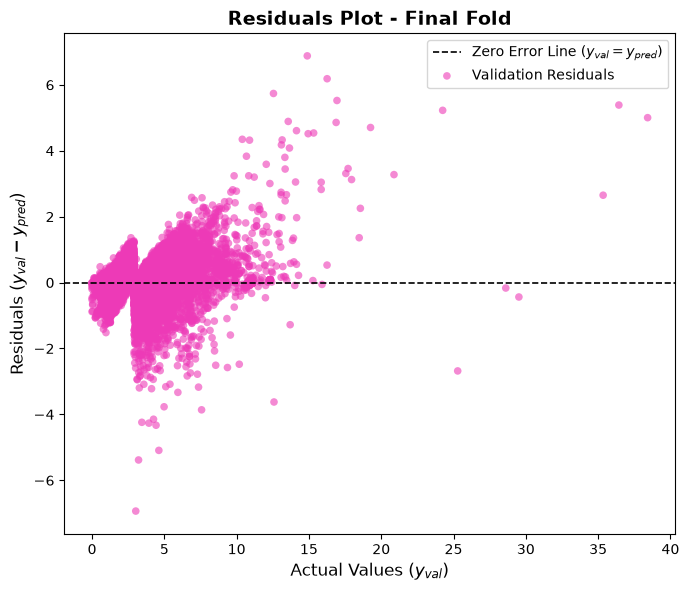

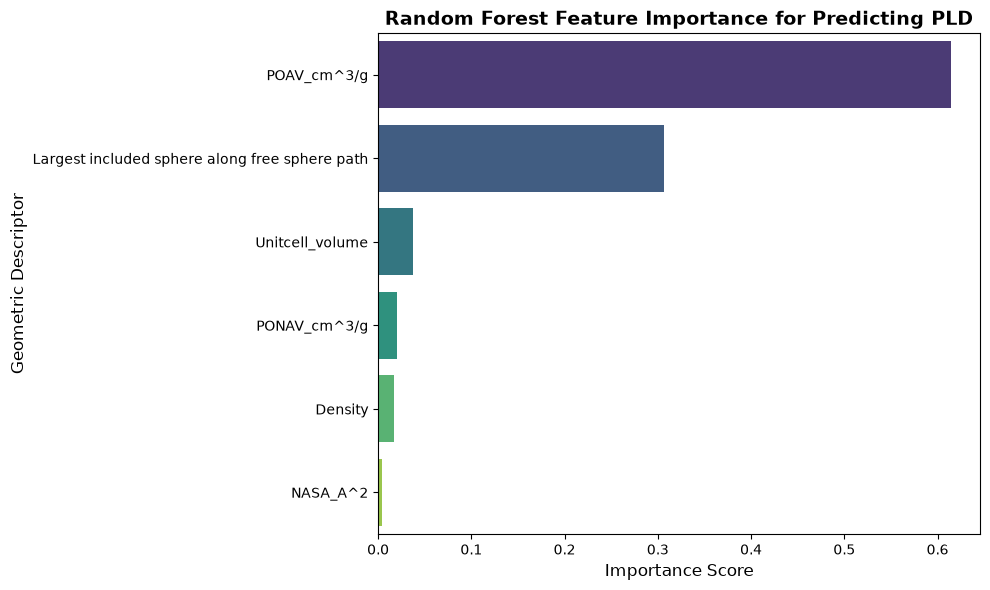

In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Define the file path
file_path = "data/model_ready_data.csv"

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Check shape
if df.shape != (124467, 8):
    print("\nERROR: Unexpected df shape... warning, code may break... continuining script anyways...\n")
else:
    print("\nData loaded...\n")

# Column of interest
PLD = "Largest free sphere" # this is what I am training to predict
print(f"Column of interest: {PLD} (aka pore limiting diameter, PLD)\n")

# Define grouping column: cif column containing CSD REFCODE
id_col = "cif"

# Isolate the target y vector as NumPy array
y = df[PLD].values

# Extract feature set X as a NumPy array
X = df.drop(columns=[id_col, PLD]).values

# Data check
print(f"Target variable shape (y): {y.shape}")
print(f"Feature matrix shape (X):  {X.shape}")
print(f"Number of predictors:      {X.shape[1]}")
print("Predictor Columns:")
print([col for col in df.columns if col not in [id_col, PLD]])

# Extract just the first 6 characters to capture root CSD REFCODE
groups = df[id_col].astype(str).values

# Initialize GroupKFold cross-validator and number of folds 
n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

# Initialize the Random Forest Regressor and n_estimators
n_estimators = 100
rf_model = RandomForestRegressor(n_estimators=n_estimators, random_state=42, n_jobs=-1)
print(f"\nInitialized GroupKFold with {n_splits} splits.")
print(f"Initialized RandomForestRegressor with {n_estimators} n_estimators.\n")

# Create empty lists to track validation scores across the folds
r2_scores = []
mae_scores = []
rmse_scores = []
# also collect training scores
r2_scores_train = []
mae_scores_train = []
rmse_scores_train = []

# Begin RF modeling
print(f"Beginning {n_splits}-Fold GroupKFold Cross-Validation...\n")

# Loop through fold iteration from enumerating GroupKFold
for fold, (training_rows, validation_rows) in enumerate(gkf.split(X, y, groups=groups), 1):

    # Splitting test/train data
    X_train, X_val = X[training_rows], X[validation_rows]
    y_train, y_val = y[training_rows], y[validation_rows]
    
    # Training the model on training splits
    rf_model.fit(X_train, y_train)
    
    # Predicting with test data using trained model
    y_pred = rf_model.predict(X_val)

    # Predicting with train data as well
    y_pred_train = rf_model.predict(X_train)
    
    # Calculate accuracy/error metrics for the current fold
    r2 = r2_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    # Repeat for training data
    r2_train = r2_score(y_train, y_pred_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    
    # Store metrics
    r2_scores.append(r2)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    # Repeat for training metrics
    r2_scores_train.append(r2_train)
    mae_scores_train.append(mae_train)
    rmse_scores_train.append(rmse_train)

    # Print fold metrics
    print(f"Fold #{fold} -> R²: {r2:.4f} | MAE: {mae:.4f} Å | RMSE: {rmse:.4f} Å")

# Reporting performance
print("\nModel Performance Summary")
print(f"R² Score:     {np.mean(r2_scores):.4f} (± {np.std(r2_scores):.4f})")
print(f"MAE:  {np.mean(mae_scores):.4f} Å (± {np.std(mae_scores):.4f} Å)")
print(f"RMSE: {np.mean(rmse_scores):.4f} Å (± {np.std(rmse_scores):.4f} Å)")
print("\nCheck - Training Data Performance Summary")
print(f"R² Score:     {np.mean(r2_scores_train):.4f} (± {np.std(r2_scores_train):.4f})")
print(f"MAE:  {np.mean(mae_scores_train):.4f} Å (± {np.std(mae_scores_train):.4f} Å)")
print(f"RMSE: {np.mean(rmse_scores_train):.4f} Å (± {np.std(rmse_scores_train):.4f} Å)")

# compile fold results
df_results = pd.DataFrame({
    'Fold': range(1, len(r2_scores) + 1),
    'R2_Train': r2_scores_train,
    'R2_Val': r2_scores,
    'MAE_Train': mae_scores_train,
    'MAE_Val': mae_scores,
    'RMSE_Train': rmse_scores_train,
    'RMSE_Val': rmse_scores
})

# Save the k-fold results 
df_results.to_csv("data/results_metrics.csv", index=False)

# Get final fold R^2 score for parity plot
final_r2 = r2_scores[n_splits - 1]

# Set up the figure and axis for parity plot
plt.figure(figsize=(7, 6))

# Store minimum and maximum for scaling axes
min_val = min(min(y_val), min(y_pred))
max_val = max(max(y_val), max(y_pred))

# Padding for axis
padding = (max_val - min_val) * 0.05
line_x = np.linspace(min_val - padding, max_val + padding, 200)

# Plot diagonal line and the shaded region
plt.plot(line_x, line_x, 'k--', lw=1.2, label='Ideal ($y=x$)')
plt.fill_between(
    line_x, 
    line_x - 0.05*max_val, 
    line_x + 0.05*max_val, 
    color='gray', 
    alpha=0.2,
    label='$\pm 5$% Error Band'
)

# Scatter plot the final fold data
plt.scatter(
    y_val, 
    y_pred, 
    color='#7C3AED',
    alpha=0.6, 
    s=30, 
    edgecolor='none', 
    label='Validation Samples'
)

# Set titles, labels, limits, styling
plt.title(f'Parity Plot - Final Fold ($R^2 = {final_r2:.3f}$)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Values ($y_{val}$)', fontsize=12)
plt.ylabel('Predicted Values ($y_{pred}$)', fontsize=12)
plt.xlim(min_val - padding, max_val + padding)
plt.ylim(min_val - padding, max_val + padding)
plt.grid(False)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()

# Save the figure
plt.savefig('figures/parity_plot.png', dpi=150, bbox_inches='tight')

# Calculate residuals for residuals plot
residuals = np.array(y_val) - np.array(y_pred)

# Set up the figure for residuals plot
plt.figure(figsize=(7, 6))

# Add horizontal line 
plt.axhline(0, color='black', linestyle='--', linewidth=1.2, label='Zero Error Line ($y_{val} = y_{pred}$)')

# Scatter plot the points
plt.scatter(
    y_val, 
    residuals, 
    color="#ED3AB7",
    alpha=0.6, 
    s=30, 
    edgecolor='none', 
    label='Validation Residuals'
)

# Set titles, axis labels, legend, and styling
plt.title('Residuals Plot - Final Fold', fontsize=14, fontweight='bold')
plt.xlabel('Actual Values ($y_{val}$)', fontsize=12)
plt.ylabel('Residuals ($y_{val} - y_{pred}$)', fontsize=12)
plt.grid(False)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()

# Save the figure
plt.savefig('figures/residuals_plot.png', dpi=150, bbox_inches='tight')

# Extract feature importances from the trained random forest model
importances = rf_model.feature_importances_

# New data frame for feature names and associated scores
feature_names = [col for col in df.columns if col not in [id_col, PLD]]
df_importance = pd.DataFrame({'Feature': feature_names,'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Random Forest Feature Importance for Predicting PLD', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Geometric Descriptor', fontsize=12)
plt.tight_layout()

# Save figure
plt.savefig('figures/feature_importances.png', dpi=150, bbox_inches='tight')

print("\nModeling complete -> proceed to 04_results_visualization....")